In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    log_loss,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

In [5]:
data_path = os.path.abspath(os.path.join(os.path.abspath(os.curdir), os.pardir) + "\\data\\response_retail\\")
data_path

'C:\\git\\ML-hands-on-notebooks\\data\\response_retail'

In [9]:
df = pd.read_csv(
    data_path + "\\fashion_retail_customer_campaign_history.csv",
    parse_dates=["campaign_date"]
)

print(df.shape)
df.head()

# one row = one customer * one campaign

(1000000, 35)


,customer_id,age,gender,segment,loyalty_tier,orders_30d,orders_90d,orders_180d,spend_30d,spend_90d,...,opened,clicked,response_probability,responded,order_value,prior_campaigns,prior_responses,prior_response_rate,previous_response,campaign_gap_days
0,CUST000001,18,Male,Occasional,Bronze,0,0,2,0.0,0.0,...,1,0,0.162827,1,24.46,0,0,0.000000,0.0,999.0
1,CUST000001,18,Male,Occasional,Bronze,0,0,2,0.0,0.0,...,1,1,0.249741,0,0.00,1,1,1.000000,1.0,25.0
2,CUST000001,18,Male,Occasional,Bronze,0,0,2,0.0,0.0,...,1,0,0.106493,0,0.00,2,1,0.500000,0.0,25.0
3,CUST000001,18,Male,Occasional,Bronze,0,0,2,0.0,0.0,...,1,0,0.115558,0,0.00,3,1,0.333333,0.0,25.0
4,CUST000001,18,Male,Occasional,Bronze,0,0,2,0.0,0.0,...,0,0,0.166733,0,0.00,4,1,0.250000,0.0,25.0


In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'segment', 'loyalty_tier', 'orders_30d',
       'orders_90d', 'orders_180d', 'spend_30d', 'spend_90d', 'spend_180d',
       'aov', 'recency_days', 'discount_affinity', 'return_rate',
       'preferred_category', 'preferred_channel', 'campaign_id',
       'campaign_name', 'channel', 'category', 'offer_type', 'discount_pct',
       'campaign_type', 'campaign_date', 'opened', 'clicked',
       'response_probability', 'responded', 'order_value', 'prior_campaigns',
       'prior_responses', 'prior_response_rate', 'previous_response',
       'campaign_gap_days'],
      dtype='object')

In [11]:
df["campaign_name"].value_counts()

campaign_name
Summer Dresses        50000
Denim Days            50000
New Arrivals          50000
Sneaker Weekend       50000
Member Exclusive      50000
Festive Edit          50000
Flash Sale            50000
Activewear Drop       50000
Winter Layers         50000
Premium Collection    50000
End of Season         50000
Denim Refresh         50000
Occasion Edit         50000
Sneaker Launch        50000
Loyalty Weekend       50000
Spring Refresh        50000
Member Flash Sale     50000
Summer Essentials     50000
Accessory Edit        50000
Festive Finale        50000
Name: count, dtype: int64

In [14]:
df[df["customer_id"] == 'CUST000001'][["opened","clicked","response_probability","responded","order_value","prior_campaigns","prior_responses", "campaign_date", "campaign_name"]]

,opened,clicked,response_probability,responded,order_value,prior_campaigns,prior_responses,campaign_date,campaign_name
0,1,0,0.162827,1,24.46,0,0,2025-01-15 00:00:00.000000000,Summer Dresses
1,1,1,0.249741,0,0.00,1,1,2025-02-09 12:37:53.684210526,Denim Days
2,1,0,0.106493,0,0.00,2,1,2025-03-07 01:15:47.368421052,New Arrivals
3,1,0,0.115558,0,0.00,3,1,2025-04-01 13:53:41.052631579,Sneaker Weekend
4,0,0,0.166733,0,0.00,4,1,2025-04-27 02:31:34.736842105,Member Exclusive
5,1,1,0.647099,1,24.56,5,1,2025-05-22 15:09:28.421052632,Festive Edit
6,0,0,0.208261,1,24.19,6,2,2025-06-17 03:47:22.105263158,Flash Sale
7,1,0,0.221808,0,0.00,7,3,2025-07-12 16:25:15.789473684,Activewear Drop
8,0,0,0.062519,0,0.00,8,3,2025-08-07 05:03:09.473684210,Winter Layers
9,1,0,0.142226,0,0.00,9,3,2025-09-01 17:41:03.157894736,Premium Collection


In [15]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

customer_id             0
age                     0
gender                  0
segment                 0
loyalty_tier            0
orders_30d              0
orders_90d              0
orders_180d             0
spend_30d               0
spend_90d               0
spend_180d              0
aov                     0
recency_days            0
discount_affinity       0
return_rate             0
preferred_category      0
preferred_channel       0
campaign_id             0
campaign_name           0
channel                 0
category                0
offer_type              0
discount_pct            0
campaign_type           0
campaign_date           0
opened                  0
clicked                 0
response_probability    0
responded               0
order_value             0
prior_campaigns         0
prior_responses         0
prior_response_rate     0
previous_response       0
campaign_gap_days       0
dtype: int64

In [16]:
df["responded"].value_counts(normalize=True)

#TARGET = "responded"
#responded = 1
#Customer purchased/responded within the campaign response window.

responded
0    0.74449
1    0.25551
Name: proportion, dtype: float64

In [17]:
#response by campaign
campaign_response = (
    df.groupby(
        [
            "campaign_id",
            "campaign_name"
        ]
    )
    .agg(
        customers=("customer_id", "nunique"),
        responses=("responded", "sum"),
        response_rate=("responded", "mean"),
        revenue=("order_value", "sum")
    )
    .reset_index()
)



campaign_response.sort_values(
        "response_rate",
        ascending=False
    )

,campaign_id,campaign_name,customers,responses,response_rate,revenue
19,CMP020,Festive Finale,50000,20740,0.41480,1295396.77
10,CMP011,End of Season,50000,20726,0.41452,1192289.39
6,CMP007,Flash Sale,50000,19377,0.38754,1211430.00
16,CMP017,Member Flash Sale,50000,17980,0.35960,1218363.11
14,CMP015,Loyalty Weekend,50000,17708,0.35416,1278241.24
5,CMP006,Festive Edit,50000,14818,0.29636,997598.75
4,CMP005,Member Exclusive,50000,13498,0.26996,972019.68
8,CMP009,Winter Layers,50000,12646,0.25292,919520.47
17,CMP018,Summer Essentials,50000,12214,0.24428,945012.86
0,CMP001,Summer Dresses,50000,12209,0.24418,947077.78


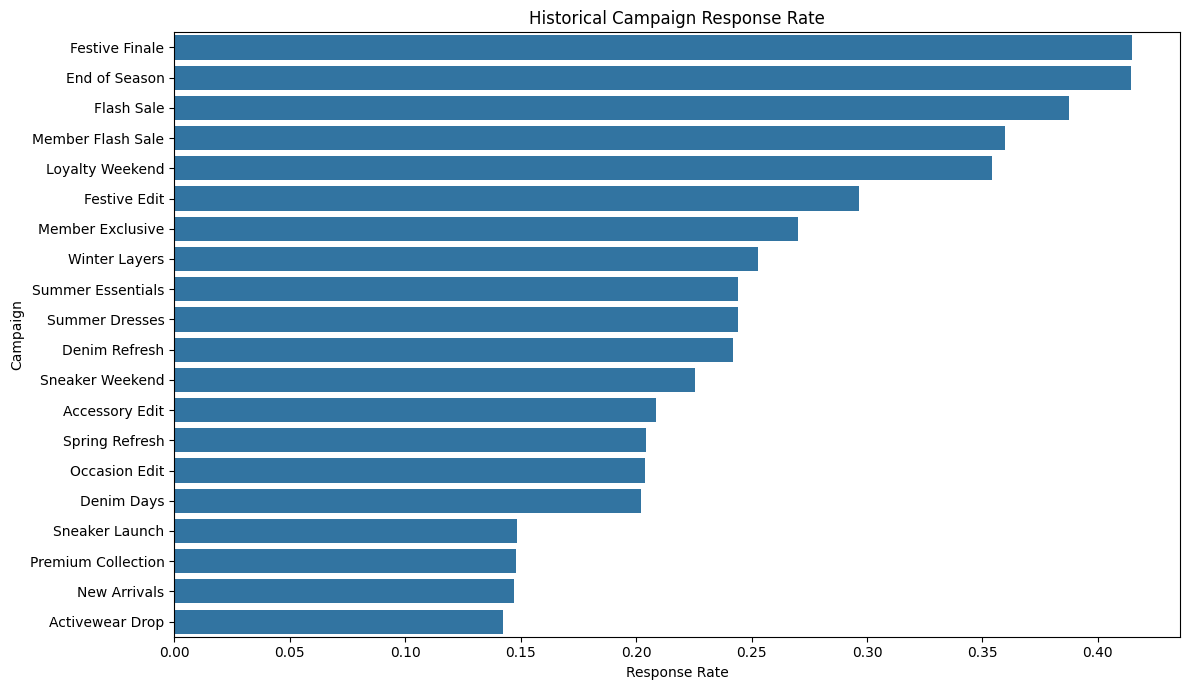

In [18]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=campaign_response.sort_values(
        "response_rate",
        ascending=False
    ),
    x="response_rate",
    y="campaign_name"
)

plt.title("Historical Campaign Response Rate")
plt.xlabel("Response Rate")
plt.ylabel("Campaign")

plt.tight_layout()
plt.show()

In [19]:
#Customer-level response behavior
segment_response = (
    df.groupby("segment")
      ["responded"]
      .mean()
      .sort_values(ascending=False)
)

print(segment_response)

segment
Loyal         0.432496
Regular       0.269116
Occasional    0.206302
At_Risk       0.169232
New           0.165620
Name: responded, dtype: float64


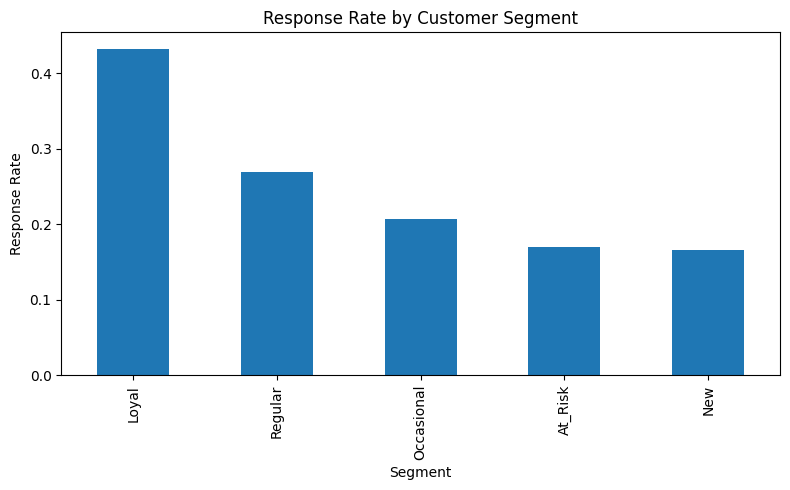

In [21]:
plt.figure(figsize=(8, 5))

segment_response.plot(
    kind="bar"
)

plt.title("Response Rate by Customer Segment")
plt.ylabel("Response Rate")
plt.xlabel("Segment")

plt.tight_layout()
plt.show()

In [22]:
#Response by channel
channel_response = (
    df.groupby("channel")
      ["responded"]
      .mean()
      .sort_values(ascending=False)
)

print(channel_response)

channel
SMS         0.34091
Email       0.28981
WhatsApp    0.18265
Push        0.17437
Name: responded, dtype: float64


In [23]:
#Response by discount
discount_response = (
    df.groupby("discount_pct")
      ["responded"]
      .mean()
      .reset_index()
)

print(discount_response)

   discount_pct  responded
0             0   0.146565
1            15   0.204580
2            20   0.238940
3            25   0.292347
4            30   0.327980
5            35   0.401170
6            40   0.414520


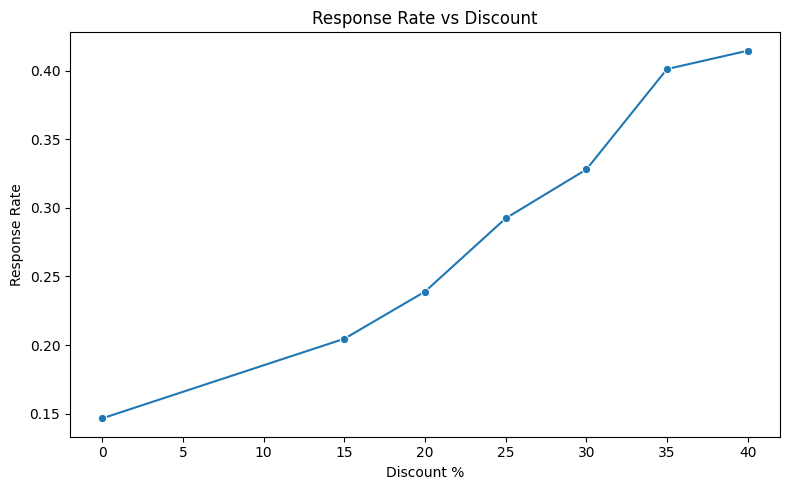

In [25]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=discount_response,
    x="discount_pct",
    y="responded",
    marker="o"
)

plt.title("Response Rate vs Discount")
plt.xlabel("Discount %")
plt.ylabel("Response Rate")

plt.tight_layout()
plt.show()

# Feature engineering

In [26]:
# additional campaign features

df["log_spend_180d"] = np.log1p(
    df["spend_180d"]
)

df["log_spend_90d"] = np.log1p(
    df["spend_90d"]
)

df["log_orders_180d"] = np.log1p(
    df["orders_180d"]
)

df["log_orders_90d"] = np.log1p(
    df["orders_90d"]
)

df["recency_score"] = 1 / (
    1 + df["recency_days"]
)

df["spend_per_order"] = (
    df["spend_180d"] /
    df["orders_180d"].clip(lower=1)
)

df["campaign_engagement_rate"] = (
    df["clicked"] /
    df["prior_campaigns"].clip(lower=1)
)

df["open_rate_history"] = (
    df["opened"] /
    df["prior_campaigns"].clip(lower=1)
)

## customer-campaign interaction features

In [27]:
#Category affinity
df["category_match"] = (
    (df["preferred_category"] == df["category"]) |
    (df["category"] == "All")
).astype(int)

In [28]:
#channel preference
df["channel_match"] = (
    df["preferred_channel"] ==
    df["channel"]
).astype(int)

In [29]:
#Discount sensitivity
df["discount_x_affinity"] = (
    df["discount_pct"] *
    df["discount_affinity"]
)

In [30]:
#Loyalty × discount
df["loyalty_discount_interaction"] = (
    (df["loyalty_tier"] == "Gold").astype(int)
    *
    df["discount_pct"]
)

# Time-based train/test split

In [31]:
numeric_features = [
    "age",
    "orders_30d",
    "orders_90d",
    "orders_180d",

    "spend_30d",
    "spend_90d",
    "spend_180d",

    "aov",
    "recency_days",
    "discount_affinity",
    "return_rate",

    "prior_campaigns",
    "prior_responses",
    "prior_response_rate",
    "previous_response",
    "campaign_gap_days",

    "discount_pct",

    "log_spend_180d",
    "log_spend_90d",
    "log_orders_180d",
    "log_orders_90d",

    "recency_score",
    "spend_per_order",

    "category_match",
    "channel_match",
    "discount_x_affinity",
    "loyalty_discount_interaction"
]

categorical_features = [
    "gender",
    "segment",
    "loyalty_tier",
    "preferred_category",
    "preferred_channel",
    "channel",
    "category",
    "offer_type",
    "campaign_type"
]

In [32]:
df = df.sort_values(
    "campaign_date"
)

In [33]:
cutoff_date = pd.Timestamp("2026-03-01")

train = df[
    df["campaign_date"] < cutoff_date
].copy()

test = df[
    df["campaign_date"] >= cutoff_date
].copy()

print(
    "Train:",
    train.shape
)

print(
    "Test:",
    test.shape
)

print(
    "Train period:",
    train["campaign_date"].min(),
    "to",
    train["campaign_date"].max()
)

print(
    "Test period:",
    test["campaign_date"].min(),
    "to",
    test["campaign_date"].max()
)

Train: (850000, 47)
Test: (150000, 47)
Train period: 2025-01-15 00:00:00 to 2026-02-27 10:06:18.947368420
Test period: 2026-03-24 22:44:12.631578944 to 2026-05-15 00:00:00


In [37]:
test.groupby(["campaign_date"])["campaign_name"].value_counts()

campaign_date                  campaign_name    
2026-03-24 22:44:12.631578944  Summer Essentials    50000
2026-04-19 11:22:06.315789472  Accessory Edit       50000
2026-05-15 00:00:00.000000000  Festive Finale       50000
Name: count, dtype: int64

In [39]:
TARGET = "responded"
X_train = train[
    numeric_features +
    categorical_features
]

y_train = train[TARGET]

X_test = test[
    numeric_features +
    categorical_features
]

y_test = test[TARGET]

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Logistic Regression - Baseline model

In [42]:
logistic_model = Pipeline(steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(max_iter=1000, class_weight="balanced")
        )
    ])

logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
logistic_probability = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

In [44]:
roc_auc = roc_auc_score(
    y_test,
    logistic_probability
)

print(
    "Logistic ROC-AUC:",
    round(roc_auc, 4)
)

Logistic ROC-AUC: 0.7111


In [45]:
pr_auc = average_precision_score(
    y_test,
    logistic_probability
)

print(
    "Logistic PR-AUC:",
    round(pr_auc, 4)
)

Logistic PR-AUC: 0.5021


In [46]:
print(
    "Log Loss:",
    log_loss(
        y_test,
        logistic_probability
    )
)

Log Loss: 0.659017980066947


# XGBoost

In [47]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [48]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [49]:
xgb_probability = (
    xgb_model.predict_proba(
        X_test_processed
    )[:, 1]
)

In [50]:
xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_probability
)

print(
    "XGBoost ROC-AUC:",
    round(xgb_roc_auc, 4)
)

print(
    "XGBoost PR-AUC:",
    round(xgb_pr_auc, 4)
)

XGBoost ROC-AUC: 0.7094
XGBoost PR-AUC: 0.498


In [51]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],

    "ROC_AUC": [
        roc_auc,
        xgb_roc_auc
    ],

    "PR_AUC": [
        pr_auc,
        xgb_pr_auc
    ]
})

comparison

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.711136,0.502055
1,XGBoost,0.709375,0.497964


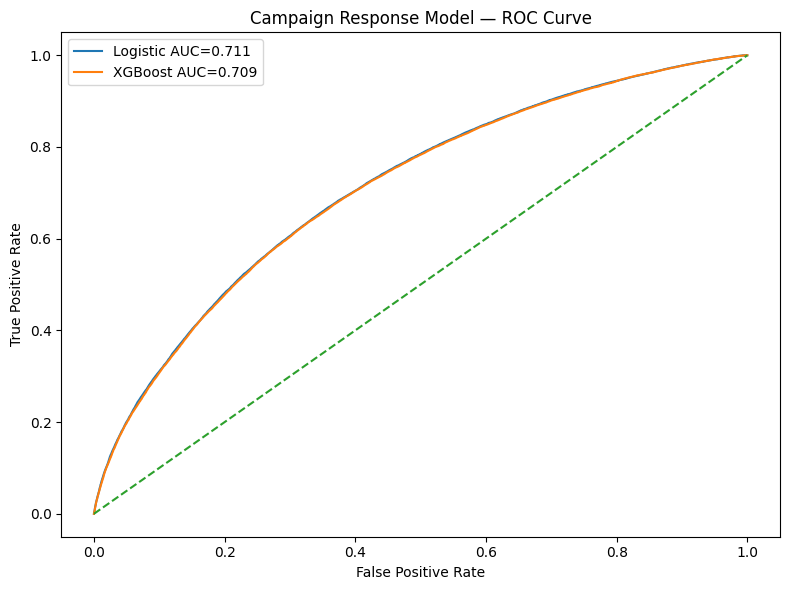

In [52]:
fpr_log, tpr_log, _ = roc_curve(
    y_test,
    logistic_probability
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic AUC={roc_auc:.3f}"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost AUC={xgb_roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Campaign Response Model — ROC Curve"
)

plt.legend()

plt.tight_layout()
plt.show()

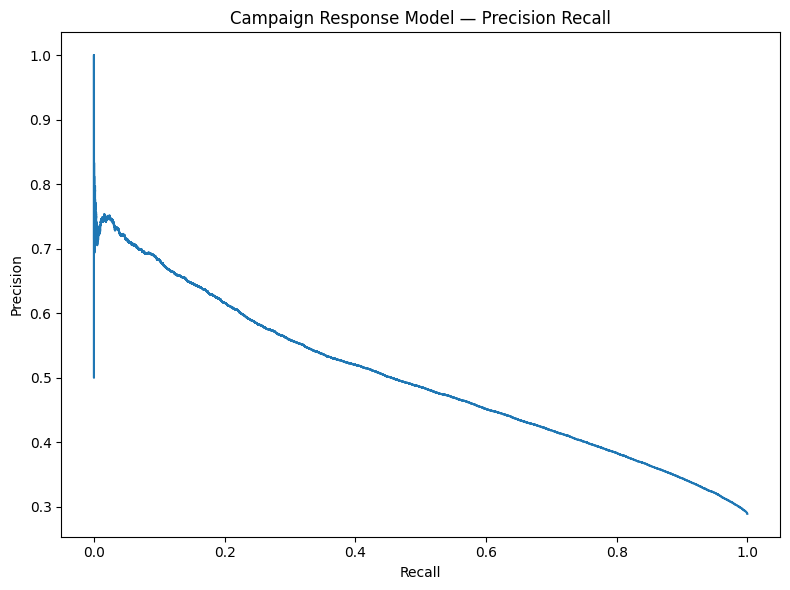

In [53]:
precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        xgb_probability
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Campaign Response Model — Precision Recall"
)

plt.tight_layout()
plt.show()

# Scoring

In [54]:
scored = test[
    [
        "customer_id",
        "campaign_id",
        "campaign_name",
        "campaign_date",
        "channel",
        "category",
        "discount_pct",
        "responded"
    ]
].copy()

scored["response_probability"] = (
    xgb_probability
)

In [56]:
scored = scored.sort_values(
    "response_probability",
    ascending=False
)


scored.head(20)

,customer_id,campaign_id,campaign_name,campaign_date,channel,category,discount_pct,responded,response_probability
246059,CUST012303,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.880049
289459,CUST014473,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,0,0.876066
922579,CUST046129,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.872433
170639,CUST008532,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.859999
235199,CUST011760,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.857763
634399,CUST031720,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.857706
216757,CUST010838,CMP018,Summer Essentials,2026-03-24 22:44:12.631578944,Email,Activewear,20,0,0.853816
622279,CUST031114,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.849615
691319,CUST034566,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.844821
591999,CUST029600,CMP020,Festive Finale,2026-05-15 00:00:00.000000000,Email,All,35,1,0.844500


# Segmenting response

In [57]:
scored["response_segment"] = pd.cut(
    scored["response_probability"],
    bins=[
        0,
        0.10,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [59]:
segment_performance = (
    scored
    .groupby("response_segment", observed=True)
    .agg(
        customers=("customer_id", "count"),
        predicted_probability=(
            "response_probability",
            "mean"
        ),
        actual_response=(
            "responded",
            "mean"
        )
    )
    .reset_index()
)

segment_performance

,response_segment,customers,predicted_probability,actual_response
0,Very Low,10176,0.079759,0.083235
1,Low,64795,0.171658,0.177838
2,Medium,59253,0.355515,0.362294
3,High,15406,0.589664,0.601908
4,Very High,370,0.781459,0.724324


# Decile/ lift analysis

In [71]:
scored["decile"] = pd.qcut(
    scored["response_probability"],
    10,
    labels=False,
    duplicates="drop"
)

# Make highest score = decile 1
scored["decile"] = (
    10 - scored["decile"]
)

In [73]:
#actual response
lift_table = (
    scored
    .groupby("decile")
    .agg(
        customers=("customer_id", "count"),
        predicted_response=(
            "response_probability",
            "mean"
        ),
        actual_response=(
            "responded",
            "mean"
        ),
        responses=("responded", "sum")
    )
    .reset_index()
)

In [76]:
#baseline response
baseline_response = (
    scored["responded"].mean()
)

baseline_response

np.float64(0.28918666666666665)

In [75]:
#lift
lift_table["lift"] = (
    lift_table["actual_response"] /
    baseline_response
)

lift_table

,decile,customers,predicted_response,actual_response,responses,lift
0,1,15000,0.598871,0.609200,9138,2.106598
1,2,15000,0.455580,0.451200,6768,1.560238
2,3,15000,0.379810,0.393800,5907,1.361750
3,4,15000,0.322026,0.332267,4984,1.148970
4,5,15000,0.272484,0.280133,4202,0.968694
5,6,15000,0.229372,0.239733,3596,0.828992
6,7,15000,0.191609,0.199533,2993,0.689981
7,8,15000,0.158819,0.164800,2472,0.569874
8,9,15000,0.128060,0.130267,1954,0.450459
9,10,15000,0.088237,0.090933,1364,0.314445


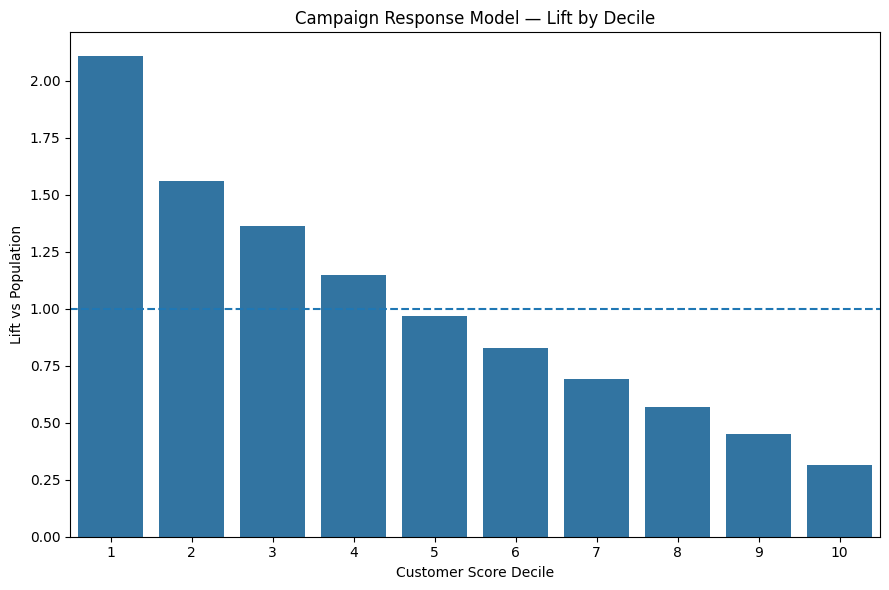

In [66]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=lift_table,
    x="decile",
    y="lift"
)

plt.axhline(1, linestyle="--")

plt.title(   "Campaign Response Model — Lift by Decile")
plt.xlabel( "Customer Score Decile")
plt.ylabel(    "Lift vs Population")
plt.tight_layout()
plt.show()

In [80]:
top_10 = scored[
    scored["response_probability"]
    >= scored["response_probability"].quantile(
        0.90
    )
].copy()

top10_response = (
    top_10["responded"].mean()
)

overall_response = (
    scored["responded"].mean()
)

print(
    "Overall response:",
    round(overall_response, 4)
)

print(
    "Top 10% response:",
    round(top10_response, 4)
)

print(
    "Lift:",
    round(
        top10_response /
        overall_response,
        2
    )
)

Overall response: 0.2892
Top 10% response: 0.6092
Lift: 2.11


# Calibrating probabilities

In [81]:
prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_probability,
    n_bins=10,
    strategy="quantile"
)

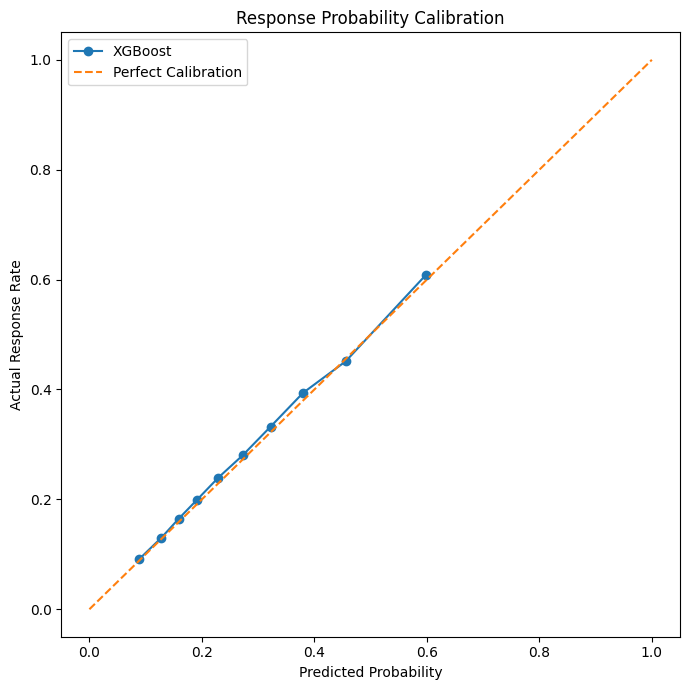

In [82]:
plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(   "Predicted Probability")
plt.ylabel(   "Actual Response Rate")
plt.title(   "Response Probability Calibration")
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
brier = brier_score_loss(
    y_test,
    xgb_probability
)

print(
    "Brier Score:",
    round(brier, 5)
)

Brier Score: 0.18173


# Predict a FUTURE campaign

Campaign:
Festive Dresses

Channel:
Email

Category:
Dresses

Discount:
30%

The future campaign itself must be an input to the model, and its nature—category, offer, channel, campaign type, timing, etc.—should influence the predicted response.

In [84]:
latest_customer = (
    df.sort_values("campaign_date")
      .groupby("customer_id")
      .tail(1)
      .copy()
)

In [85]:
future_campaign = {
    "campaign_id": "FUTURE001",
    "campaign_name": "Festive Dresses 2026",
    "channel": "Email",
    "category": "Dresses",
    "offer_type": "Percentage Discount",
    "discount_pct": 30,
    "campaign_type": "Seasonal"
}

future = latest_customer.copy()

for column, value in future_campaign.items():
    future[column] = value

In [93]:
latest_customer[["campaign_name", "campaign_date"]].value_counts()

campaign_name   campaign_date
Festive Finale  2026-05-15       50000
Name: count, dtype: int64

In [94]:
future[["campaign_name", "campaign_date"]].value_counts()

campaign_name         campaign_date
Festive Dresses 2026  2026-05-15       50000
Name: count, dtype: int64

In [95]:
future["category_match"] = (
    (future["preferred_category"]
     == future["category"])
    |
    (future["category"] == "All")
).astype(int)

future["channel_match"] = (
    future["preferred_channel"]
    == future["channel"]
).astype(int)

future["discount_x_affinity"] = (
    future["discount_pct"]
    *
    future["discount_affinity"]
)

future["loyalty_discount_interaction"] = (
    (future["loyalty_tier"] == "Gold")
    .astype(int)
    *
    future["discount_pct"]
)

In [96]:
future["log_spend_180d"] = np.log1p(
    future["spend_180d"]
)

future["log_spend_90d"] = np.log1p(
    future["spend_90d"]
)

future["log_orders_180d"] = np.log1p(
    future["orders_180d"]
)

future["log_orders_90d"] = np.log1p(
    future["orders_90d"]
)

future["recency_score"] = (
    1 /
    (1 + future["recency_days"])
)

future["spend_per_order"] = (
    future["spend_180d"] /
    future["orders_180d"].clip(lower=1)
)

future["campaign_engagement_rate"] = (
    future["clicked"] /
    future["prior_campaigns"].clip(lower=1)
)

future["open_rate_history"] = (
    future["opened"] /
    future["prior_campaigns"].clip(lower=1)
)

In [97]:
future_X = future[
    numeric_features +
    categorical_features
]

In [98]:
future_processed = (
    preprocessor.transform(
        future_X
    )
)

In [99]:
future["response_probability"] = (
    xgb_model.predict_proba(
        future_processed
    )[:, 1]
)

In [101]:
future_scores = future[
    [
        "customer_id",
        "segment",
        "loyalty_tier",
        "preferred_category",
        "preferred_channel",
        "recency_days",
        "orders_90d",
        "spend_180d",
        "response_probability"
    ]
].sort_values(
    "response_probability",
    ascending=False
)

future_scores.head(20)

,customer_id,segment,loyalty_tier,preferred_category,preferred_channel,recency_days,orders_90d,spend_180d,response_probability
922579,CUST046129,Loyal,Gold,Dresses,SMS,10,8,3442.26,0.890143
170639,CUST008532,Loyal,Gold,Activewear,SMS,11,7,5309.21,0.808761
213539,CUST010677,Loyal,Gold,Menswear,Email,3,18,3406.50,0.802728
216759,CUST010838,Loyal,Gold,Tops,Email,13,18,2948.51,0.790983
514679,CUST025734,Loyal,Gold,Dresses,Push,10,10,4137.86,0.787546
33299,CUST001665,Loyal,Gold,Dresses,Email,5,8,943.12,0.785880
49139,CUST002457,Loyal,Gold,Menswear,Email,6,7,2069.94,0.785792
75619,CUST003781,Loyal,Gold,Activewear,Email,15,7,3192.35,0.781698
481439,CUST024072,Loyal,Gold,Accessories,SMS,10,1,3439.79,0.779614
543399,CUST027170,Loyal,Gold,Dresses,WhatsApp,28,7,2696.30,0.778858


In [102]:
future_scores["target_group"] = pd.cut(
    future_scores["response_probability"],
    bins=[
        0,
        0.10,
        0.25,
        0.50,
        0.75,
        1
    ],
    labels=[
        "Do Not Target",
        "Low",
        "Medium",
        "High",
        "Priority"
    ]
)

In [103]:
priority_customers = future_scores[
    future_scores["target_group"]
    == "Priority"
]

In [104]:
priority_customers.head()

,customer_id,segment,loyalty_tier,preferred_category,preferred_channel,recency_days,orders_90d,spend_180d,response_probability,target_group
922579,CUST046129,Loyal,Gold,Dresses,SMS,10,8,3442.26,0.890143,Priority
170639,CUST008532,Loyal,Gold,Activewear,SMS,11,7,5309.21,0.808761,Priority
213539,CUST010677,Loyal,Gold,Menswear,Email,3,18,3406.50,0.802728,Priority
216759,CUST010838,Loyal,Gold,Tops,Email,13,18,2948.51,0.790983,Priority
514679,CUST025734,Loyal,Gold,Dresses,Push,10,10,4137.86,0.787546,Priority


In [ ]:
priority_customers.to_csv(
    "future_campaign_priority_customers.csv",
    index=False
)

# Estimate campaign revenue

In [105]:
expected_aov = 85

future_scores["expected_revenue"] = (
    future_scores["response_probability"]
    *
    expected_aov
)

In [106]:
expected_revenue = (
    future_scores["expected_revenue"]
    .sum()
)

print(
    "Expected campaign revenue:",
    expected_revenue
)

Expected campaign revenue: 1.2398262e+06


In [107]:
# Optimize the campaign audience
contact_cost = 0.50
gross_margin = 0.55

future_scores["expected_profit"] = (
    future_scores["response_probability"]
    *
    expected_aov
    *
    gross_margin
    -
    contact_cost
)

In [110]:
profitable_customers = future_scores[
    future_scores["expected_profit"] > 0
]

profitable_customers.head()

,customer_id,segment,loyalty_tier,preferred_category,preferred_channel,recency_days,orders_90d,spend_180d,response_probability,target_group,expected_revenue,expected_profit
922579,CUST046129,Loyal,Gold,Dresses,SMS,10,8,3442.26,0.890143,Priority,75.662186,41.114204
170639,CUST008532,Loyal,Gold,Activewear,SMS,11,7,5309.21,0.808761,Priority,68.744690,37.309582
213539,CUST010677,Loyal,Gold,Menswear,Email,3,18,3406.50,0.802728,Priority,68.231873,37.027531
216759,CUST010838,Loyal,Gold,Tops,Email,13,18,2948.51,0.790983,Priority,67.233559,36.478458
514679,CUST025734,Loyal,Gold,Dresses,Push,10,10,4137.86,0.787546,Priority,66.941391,36.317764
